In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import polars as pl
import statsmodels.api as sm
from scipy.stats import norm, t

from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from dataclasses import dataclass

**Step 1: Load data from Tardis**

In [4]:
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

# Set time and exchanges
start_time = datetime.strptime('2025-03-20', '%Y-%m-%d')
end_time = datetime.strptime('2025-03-25', '%Y-%m-%d')
exchange = 'bybit-spot' #'binance-futures'
symbol = 'btcusdt'
                    
# Load the data
trades_df = Tardis_data.read(start_time, end_time, data_type='trades', exchange=exchange, symbol=symbol)
bbo_df = Tardis_data.read(start_time, end_time, data_type='book_ticker', exchange=exchange, symbol=symbol)
order_book_25 = Tardis_data.read(start_time, end_time, data_type='book_snapshot_25', exchange=exchange, symbol=symbol)
order_book_10 = order_book_25.select(order_book_25.columns[:45])

# Add Latency Column
trades_df, bbo_df, order_book_25, order_book_10 = [
    ds.with_columns([
        (pl.col('local_timestamp') - pl.col('timestamp')).alias('recv_latency'),
        (pl.col('local_timestamp') - pl.col('timestamp')).shift(-1).alias('next_recv_latency')
    ]).filter(pl.col("next_recv_latency").is_not_null())
    for ds in [trades_df, bbo_df, order_book_25, order_book_10]
]

# Take a look at the data
trades_df.describe()

statistic,human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""3881409""","""3881409""","""3881409""",3.881409e6,3.881409e6,3.881409e6,"""3881409""",3.881409e6,3.881409e6,3.881409e6,3.881409e6
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""","""2025-03-23 00:07:12.236180""",null,null,1.7427e15,1.7427e15,2.2900e18,null,85923.396073,0.011415,44682.16528,44682.16438
"""std""",null,null,null,1.7228e11,1.7228e11,1.1205e6,null,1526.959597,0.056509,42831.766429,42831.766509
"""min""","""2025-03-20 00:00:00.080000""","""bybit-spot""","""BTCUSDT""",1.7424e15,1.7424e15,2.2900e18,"""buy""",83173.0,0.000001,37700.0,37700.0
"""25%""","""2025-03-20 22:04:46.176000""",null,null,1.7425e15,1.7425e15,2.2900e18,null,84318.7,0.000392,39834.0,39834.0
"""50%""","""2025-03-23 11:09:28.367000""",null,null,1.7427e15,1.7427e15,2.2900e18,null,85869.4,0.001622,40672.0,40672.0
"""75%""","""2025-03-24 19:08:42.863000""",null,null,1.7428e15,1.7428e15,2.2900e18,null,87355.5,0.009984,41675.0,41675.0
"""max""","""2025-03-25 23:59:58.070000""","""bybit-spot""","""BTCUSDT""",1.7429e15,1.7429e15,2.2900e18,"""sell""",88773.5,10.086762,2.226729e6,2.226729e6


**Step 2: Plot the col distribution, mostly used for calibrate the mapping parameters**

Usage:
1. "rolling_vwap_std" - map 'vwap_std' to 'spread' via a linear function
2. "target_return_normalized" - map 'target_return' to 'feature_skew' via a arctan function

In [6]:
def dist_plot(grouped_df: pl.DataFrame, column: str) -> None:
    # Convert the 'price' column to a Pandas Series for plotting
    price_data = grouped_df[column].to_pandas()

    # Plot histogram
    plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# dist_plot(df, 'rolling_vwap_std')

**Step 3: Group trades and get the single trade feature we need, depends on the exchanges**

**Exchange Details**

1. Bybit: same local timestamp for same bag of trades

**Fixed Window Size Details**

Feature Window = **1000 (10min)**, Vol Window = **200 (2mins)**

In [9]:
def resample_trades_data(raw_df: pl.DataFrame, data_span_days: int = 1, exchange: str = 'Bybit', vol_window: int = 200) -> pl.DataFrame():
    '''
    Step 1: Resample the raw transcation data into single trade (depends on the rule of exchanges)
    Step 2: Calculate basic features for each single trade, which will be used in aggregation features later
    Step 3: Filter significant trades by volume - to make sure that we always have aroud 100 valid data point per minute
    
    Single Trade Feature: 'vwap', 'volume', 'initial_price'
    Regime Feature (after filter): 'vwap_diff', 'vwap_diff_square'
    '''
    # Feature of single trade (volume, vwap)
    if exchange == 'Bybit':
        grouped_trades = raw_df.group_by("local_timestamp").agg(
            pl.col("human_time").first().alias("human_time"),
            pl.col("timestamp").first().alias("exch_time"),
            pl.col("recv_latency").first().alias("recv_latency"),
            pl.col("price").first().alias("initial_price"),
            pl.col("side").first().alias("side"),
            ((pl.col("price") * pl.col("amount")).sum() / pl.col("amount").sum()).alias("vwap"),
            pl.col("amount").sum().alias("volume"),
        )
    else:
        raise AttributeError('Only support Bybit for now')
    
    # Choose the volume threshold to make that we can have 100 valid trade per minute on average
    min_sample_ratio = (data_span_days * 1440 * 100) / grouped_trades.shape[0] #we need 100 trades per minute
    volume_threshold = grouped_trades.select(pl.col("volume").quantile(1 - min_sample_ratio)).to_numpy()[0][0]
    print(f'volume_threshold: {volume_threshold}')
    
    # Feature of vwap diff between filtered data points - Used for vol calculation
    filter_trades = grouped_trades.lazy().filter(
        pl.col("volume") >= volume_threshold
    ).sort('local_timestamp').with_columns(
        (((pl.col('vwap').diff())/pl.col('vwap')*10000)).alias('vwap_diff'),
        (((pl.col('vwap').diff())/pl.col('vwap')*10000).pow(2)).alias('vwap_diff_square'),
    ).drop_nulls().with_row_index().with_columns(
        pl.mean("vwap_diff_square").rolling(index_column="index", period=f"{vol_window}i").pow(0.5).alias(f'rolling_vwap_std')
    ).collect()
    
    return filter_trades

**Step 4: Calculate aggregation features**

In [11]:
def agg_feature(grouped_df: pl.DataFrame, feature_window: int, winsorize_features: list[str] = [], winsorize_qtl: float = 0.99) -> pl.DataFrame:
    '''
    Calculate the aggregation features and drop outliers via winsorize
    
    Features: "vwap_diff_sum", "buy_count_ratio", "vwap"
    
    Features that need to be winsorized: ""
    '''
    # Keep the local_timestap as the common column to merge with valid dp in future process
    agg_feature_df = grouped_df.rolling(index_column="index", period=f"{feature_window}i").agg(
        pl.col('local_timestamp').first(),
        pl.col('vwap_diff').filter(pl.col('side') == 'buy').sum().alias('buy_vwap_diff_sum'),
        pl.col('vwap_diff').filter(pl.col('side') == 'sell').sum().abs().alias('sell_vwap_diff_sum'),
        (pl.col('side').filter(pl.col('side') == 'buy').count() / feature_window).alias('buy_count_ratio'),
        pl.col('vwap').last().alias('vwap')
    )
    
    # Drop data in the warm-up period
    agg_feature_df = agg_feature_df[feature_window:].fill_nan(0)
    
    # Drop outliers via winsorize over entire sample
    for feature in winsorize_features:
        up_limit = agg_feature_df[feature].quantile(winsorize_qtl)
        agg_feature_df = agg_feature_df.with_columns(
            pl.when(pl.col(feature) >= up_limit).then(up_limit).otherwise(pl.col(feature)).alias(feature),
        )    
    
    return agg_feature_df.sort('index').drop('index').with_row_index()
    

In [12]:
def rolling_zscore(agg_df: pl.DataFrame, zscore_window: int = 1000) -> pl.DataFrame:
    '''
    Calculate the rolling z-score of features.
    
    Default: All features will be replaced by their rolling z-score
    '''    
    zscore_df = agg_df.rolling(index_column="index", period=f"{zscore_window}i").agg(
        pl.col('local_timestamp').first(),
        ((pl.col('buy_vwap_diff_sum').last() - pl.col('buy_vwap_diff_sum').mean()) / pl.col('buy_vwap_diff_sum').std()).alias('buy_vd_z'),
        ((pl.col('sell_vwap_diff_sum').last() - pl.col('sell_vwap_diff_sum').mean()) / pl.col('sell_vwap_diff_sum').std()).alias('sell_vd_z'),
        ((pl.col('buy_count_ratio').last() - pl.col('buy_count_ratio').mean()) / pl.col('buy_count_ratio').std()).alias('bcount_z'),
        ((pl.col('vwap').last() - pl.col('vwap').mean()) / pl.col('vwap').std()).alias('vwap_z'),
    )
    
    # Drop data in the warm-up period
    zscore_df = zscore_df[zscore_window:].fill_nan(0)
    
    return zscore_df

**Step 5: Observation Sampling and Set Target Variable**

In [14]:
def ob_stv(grouped_df: pl.DataFrame, beta_vol: float, fixed_spread: float, blind_spot_ms: int = 20_000, offset: int = -10_000_000, latency_thres: int = 100_000) -> pl.DataFrame:
    '''
    Step 1: Filtering the samples that we care (where we more likely to trade)
    
    Step 2: Set a apropriate target variable - vwap diff between current significant trade and next opposite significant trade 
    
    Step 3: Normalize the target variable with rolling vwap std (which is also required by production)
    
    Step 4: Filter out high latency data points
    '''
    # Step 1: Valid vwap diff should meet such condition: last trade should be the most recent one happened at least 15ms before
    target_df = grouped_df.with_columns(
        pl.last("vwap").rolling(index_column="exch_time", offset=f'{offset}i', period=f'{-blind_spot_ms-offset}i').alias(f'rolling_{int(blind_spot_ms/1000)}ms_vwap')
    ).drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col(f'rolling_{int(blind_spot_ms/1000)}ms_vwap')) / pl.col('vwap') * 10_000).alias(f'valid_vwap_diff')
    )
    
    # Step 2.1: Calculate the spread we will set in production, to filter the significant trade we most care about
    target_df = target_df.with_columns(
        (pl.col("rolling_vwap_std") * beta_vol + fixed_spread).alias('prod_spread')
    ).filter(
        (pl.col('valid_vwap_diff').abs() >= pl.col('prod_spread'))
    )
        
    # Step 2.2: Calculate the target varible: current_vawp - next_opposite_trade_vwap
    target_df = target_df.with_columns(
        (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('bucket_id')
    )
    
    # Step 2.3: Get the next opposite trade vwap
    target_df_2 = target_df.select(
        (pl.col('bucket_id') - 1).alias('bucket_id'),
        pl.col('vwap').alias('vwap')
    ).group_by('bucket_id').agg(
        pl.col('vwap').first().alias('next_trade_price')
    )
    
    # Step 2.4: Merge it back to original df, then we can get our target variable
    target_df = target_df.join(target_df_2, on='bucket_id', how='left').drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col('next_trade_price')) / pl.col('vwap') * 10000).alias('target_return_bps')
    )
    
    # Step 3: Normalize target variable with rolling vwap std
    target_df = target_df.with_columns(
        (pl.col('target_return_bps') / pl.col('rolling_vwap_std')).alias('target_return_normalized')
    )

    # Step 4: Final filter - filter out repetition samples which are too close to each other and high latency samples
    target_df = target_df.filter(
        pl.col('exch_time').diff() >= blind_spot_ms,
        pl.col('recv_latency') <= latency_thres
    )
    
    return target_df

**Step 6: Linear Regression**

In [15]:
def linreg(target_df: pl.DataFrame, feature_df: pl.DataFrame, target: str, feature_list: list[str], merge_col: str ='local_timestamp') -> None:
    '''
    Run the linear regression
    '''
    lr_df = target_df.select(
        pl.col(merge_col),
        pl.col(target)
    ).join(feature_df, on=merge_col, how='left').drop_nulls()
    
    df = lr_df.to_pandas()

    # Define the feature columns and the target column
    X = df[feature_list]  # Feature columns
    y = df[target]  # Target column

    # Add a constant column (intercept) to the feature columns for statsmodels
    X = sm.add_constant(X)

    # Run regression and print result
    model = sm.OLS(y, X).fit()
    print(model.summary())
    
    return lr_df

**Final Step: Hyperparameters**

In [375]:
@dataclass
class DataProcessParas:
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    data_span_days: int = 1,
    exchange: str = 'Bybit',
    
    # Step 4: Calculate aggregation features
    feature_window: int = 100, # Aggregation feature window
    winsorize_features: list[str] = [], # List of features that require winsorize on total sample
    winsorize_qtl: float = 0.99,
    zscore_window: int = 1000,
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol: float = 2,
    fixed_spread: float = 0.5,
    
    # Step 6: Linear Regression
    target: str = 'target_return_normalized'
    lr_features: list[str] = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'vwap_z'], # Features that used in linear regression
    merge_col: str = 'local_timestamp' # Col that used to merge target df and feature df

#### Test 1

In [381]:
hyper_paras = DataProcessParas(
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    data_span_days = 5, 
    
    # Step 4: Calculate aggregation features
    feature_window = 100,
    winsorize_features = [],
    winsorize_qtl = 0.99,
    zscore_window = 1000,
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol = 0.5,
    fixed_spread = 0.5,
    
    # Step 6: Linear Regression
    target = 'target_return_bps',
    lr_features = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'vwap_z'],
    merge_col = 'local_timestamp'
)

volume_threshold: 0.06290699999999999


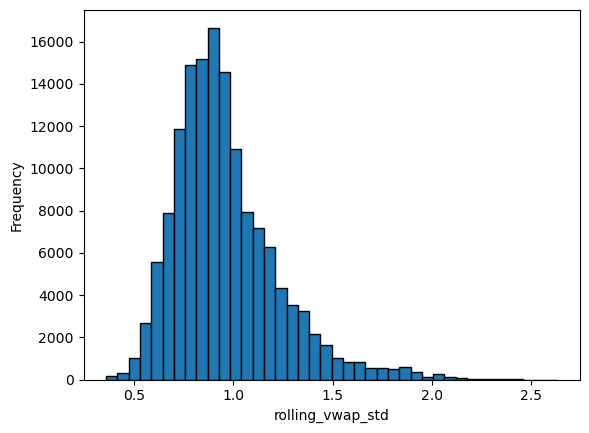

In [383]:
grouped_df = resample_trades_data(trades_df)
dist_plot(grouped_df, 'rolling_vwap_std')

In [385]:
feature_df = agg_feature(grouped_df, hyper_paras.feature_window, hyper_paras.winsorize_features, hyper_paras.winsorize_qtl)
feature_df = rolling_zscore(feature_df, hyper_paras.zscore_window)

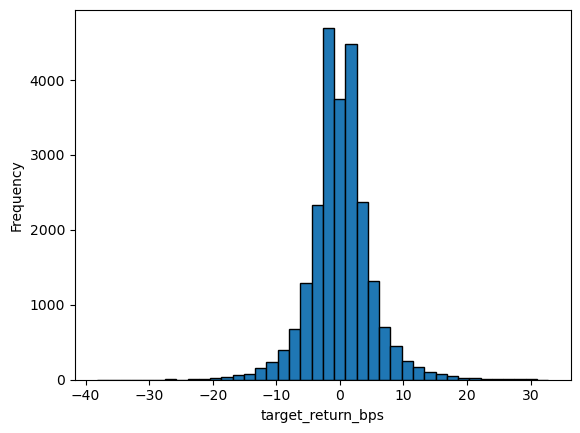

In [403]:
target_df = ob_stv(grouped_df, hyper_paras.beta_vol, hyper_paras.fixed_spread)
dist_plot(target_df, hyper_paras.target)

In [409]:
lr_df = linreg(target_df, feature_df, hyper_paras.target, hyper_paras.lr_features, hyper_paras.merge_col)

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     6.186
Date:                Sat, 05 Apr 2025   Prob (F-statistic):           5.69e-05
Time:                        23:23:31   Log-Likelihood:                -70368.
No. Observations:               23576   AIC:                         1.407e+05
Df Residuals:                   23571   BIC:                         1.408e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0707      0.031      2.266      0.0

In [411]:
lr_df

local_timestamp,target_return_bps,index,buy_vd_z,sell_vd_z,bcount_z,vwap_z
i64,f64,u32,f64,f64,f64,f64
1742428814328828,-1.747349,1106,-0.592026,0.016189,-0.839911,-1.80823
1742428817615820,1.283392,1118,-0.618524,-1.598728,-1.456773,-2.021134
1742428818247053,0.044234,1123,-0.33383,-1.719874,-1.56621,-2.068982
1742428819562563,2.916725,1130,-0.185344,-0.72025,-1.289836,-1.936702
1742428829775730,1.313087,1136,-0.239297,-1.284164,-0.894017,-1.92192
…,…,…,…,…,…,…
1742943229060547,-1.312459,143973,0.264387,-0.6955,1.157074,1.377633
1742943261157767,-2.385386,143978,-0.239703,-0.232378,0.484145,1.205308
1742943265641498,0.440496,143985,-0.087942,0.186265,0.310128,1.022548


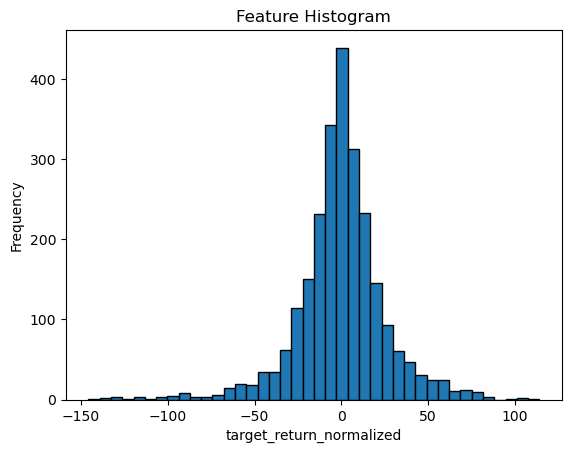

index,local_timestamp,human_time,exch_time,recv_latency,initial_price,side,vwap,volume,vwap_diff,vwap_diff_square,rolling_vwap_std,rolling_20ms_vwap,valid_vwap_diff,prod_spread
u32,i64,datetime[μs],i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
395,1742428952876240,2025-03-20 00:02:32.830,1742428952830000,46240,87008.0,"""buy""",87012.826739,0.159374,1.382168,1.91039,0.451302,86989.15403,2.7206,2.305207
400,1742428952890500,2025-03-20 00:02:32.848,1742428952848000,42500,87018.97,"""buy""",87022.075434,0.183967,0.832316,0.692751,0.439122,87000.0,2.536763,2.256486
404,1742428952900131,2025-03-20 00:02:32.858,1742428952858000,42131,87037.1,"""buy""",87037.1,0.01722,2.54719,6.488175,0.512694,87013.92,2.663232,2.550776
456,1742428953912000,2025-03-20 00:02:33.866,1742428953866000,46000,87118.29,"""buy""",87131.322097,5.0,2.923541,8.547092,0.547391,87094.99,4.169809,2.689563
459,1742428953921262,2025-03-20 00:02:33.877,1742428953877000,44262,87134.52,"""buy""",87134.592753,0.293586,2.317536,5.370972,0.616575,87096.30135,4.394512,2.966299
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
142689,1742513607058994,2025-03-20 23:33:27.016,1742513607016000,42994,84117.74,"""buy""",84119.296995,1.23885,0.863337,0.74535,0.278032,84089.167939,3.581706,1.61213
142692,1742513607062664,2025-03-20 23:33:27.017,1742513607017000,45664,84121.39,"""buy""",84124.827806,1.933166,1.699594,2.88862,0.313652,84089.167939,4.238923,1.754607
142694,1742513607071270,2025-03-20 23:33:27.029,1742513607029000,42270,84128.26,"""buy""",84129.809664,0.008,1.378782,1.901039,0.332718,84089.167939,4.830835,1.830872


In [246]:
target_df.to_pandas().to_csv('test.csv')

In [1007]:
import statsmodels.api as sm

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     44.63
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           5.02e-70
Time:                        18:25:20   Log-Likelihood:                -21884.
No. Observations:                5746   AIC:                         4.379e+04
Df Residuals:                    5737   BIC:                         4.385e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3341      0.146     

In [1027]:
import statsmodels.api as sm



                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.437
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           0.000595
Time:                        18:27:17   Log-Likelihood:                -22050.
No. Observations:                5746   AIC:                         4.411e+04
Df Residuals:                    5743   BIC:                         4.413e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3550      0.148     

In [951]:
import statsmodels.api as sm

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     47.55
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           1.03e-74
Time:                        18:19:27   Log-Likelihood:                -21870.
No. Observations:                5745   AIC:                         4.376e+04
Df Residuals:                    5736   BIC:                         4.382e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3203      0.148     

In [967]:
import statsmodels.api as sm

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     41.24
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           1.43e-64
Time:                        18:20:22   Log-Likelihood:                -21886.
No. Observations:                5743   AIC:                         4.379e+04
Df Residuals:                    5734   BIC:                         4.385e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3172      0.147     

In [991]:

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     33.51
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           4.51e-52
Time:                        18:24:37   Log-Likelihood:                -21927.
No. Observations:                5746   AIC:                         4.387e+04
Df Residuals:                    5737   BIC:                         4.393e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3444      0.145     

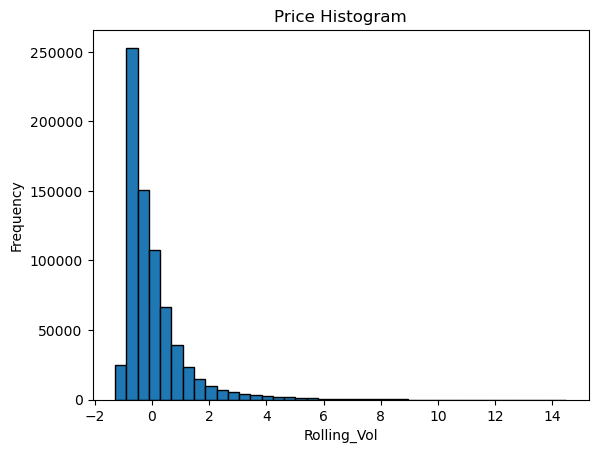

In [812]:
# Convert the 'price' column to a Pandas Series for plotting
price_data = df_fe_10_z['buy_vm_z_score'].to_pandas()

# Plot histogram
plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
plt.title('Price Histogram')
plt.xlabel('Rolling_Vol')
plt.ylabel('Frequency')
plt.show()

In [607]:
return_window = 15000

df_os_1 = spread_df.lazy().with_columns(
    pl.first("vwap").rolling(index_column="exch_time", period=f"{return_window}i").alias(f'rolling_10ms_vwap')
).with_columns(
    ((pl.col('vwap') - pl.col('rolling_10ms_vwap')) / pl.col('vwap') * 10000).alias(f'rolling_10ms_vwap_diff')
).with_columns(
    pl.max_horizontal(
        pl.col('rolling_10ms_vwap_diff').abs(),
        pl.col('vwap_diff').abs()
    ).alias('max_delta')
).collect()

In [859]:
beta_vol = 2
fixed_spread = 0.5

return_df = df_os_1.lazy().with_columns(
    (pl.col("rolling_vol") * beta_vol + fixed_spread).alias('spread')
).collect()

valid_df = return_df.filter(
    (pl.col('max_delta').abs() >= pl.col('spread'))
).with_columns(
    (pl.col("rolling_10ms_vwap").diff().abs() / pl.col("rolling_10ms_vwap") * 10000).alias('diff_between_two_dp')
).filter(
    pl.col('diff_between_two_dp') >= 0.5
).with_columns(
    (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('bucket_id')
)

In [861]:
valid_df

index,local_timestamp,human_time,exch_time,vwap,volume,initial_price,side,recv_latency,slippage,vwap_diff,vwap_diff_square,book_impact,rolling_vol,rolling_10ms_vwap,rolling_10ms_vwap_diff,max_delta,spread,diff_between_two_dp,bucket_id
u32,i64,datetime[μs],i64,f64,f64,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
38,1742428809625727,2025-03-20 00:00:09.585,1742428809585000,86862.88,0.003407,86862.88,"""sell""",40727,0.0,-0.857386,0.735111,215.765011,0.455214,86878.307718,-1.7761,1.7761,1.410429,0.719718,0
109,1742428817617049,2025-03-20 00:00:17.577,1742428817577000,86935.03,0.102067,86935.03,"""buy""",40049,1.6739e-12,0.107176,0.011487,0.112542,0.232938,86926.34052,0.999537,0.999537,0.965876,5.52569,1
119,1742428818258641,2025-03-20 00:00:18.217,1742428818217000,86904.77,0.013701,86904.77,"""sell""",41641,0.0,-0.628274,0.394728,28.810168,0.349287,86917.47827,-1.462321,1.462321,1.198574,1.019617,2
147,1742428829775730,2025-03-20 00:00:29.733,1742428829733000,86889.449342,0.40356,86894.99,"""sell""",42730,0.637627,-1.50362,2.260873,5.602321,0.492419,86902.515044,-1.503716,1.503716,1.484839,1.72184,2
307,1742428922255423,2025-03-20 00:02:02.215,1742428922215000,86906.534582,0.008278,86904.77,"""buy""",40423,0.203048,0.663086,0.439683,53.114672,0.387984,86894.838132,1.345865,1.345865,1.275967,0.883472,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
719216,1743032465170245,2025-03-26 23:41:05.131,1743032465131000,86857.130331,0.4562,86859.5,"""sell""",39245,0.272816,-0.272855,0.07445,0.163196,0.202237,86865.477507,-0.961024,0.961024,0.904474,1.556717,2026
719340,1743032538102772,2025-03-26 23:42:18.059,1743032538059000,86837.010708,1.021516,86835.1,"""buy""",43772,0.220039,0.594046,0.35289,0.345457,0.329965,86826.7,1.187363,1.187363,1.15993,3.639433,2027
719683,1743033082766758,2025-03-26 23:51:22.683,1743033082683000,86855.196936,0.312152,86853.9,"""buy""",83758,0.149324,0.195235,0.038117,0.122109,0.240138,86846.2,1.035855,1.035855,0.980276,2.245349,2027


In [865]:
target_price = valid_df.with_columns(
    (pl.col('bucket_id') - 1).alias('bucket_id')
).group_by('bucket_id').agg(
    pl.col('vwap').first().alias('next_trade_price')
)

test = valid_df.join(target_price, on='bucket_id', how='left').drop_nulls().with_columns(
    ((pl.col('vwap') - pl.col('next_trade_price')) / pl.col('vwap') * 10000).alias('target_return_bps')
)

In [883]:
test

index,local_timestamp,human_time,exch_time,vwap,volume,initial_price,side,recv_latency,slippage,vwap_diff,vwap_diff_square,book_impact,rolling_vol,rolling_10ms_vwap,rolling_10ms_vwap_diff,max_delta,spread,diff_between_two_dp,bucket_id,next_trade_price,target_return_bps
u32,i64,datetime[μs],i64,f64,f64,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64
38,1742428809625727,2025-03-20 00:00:09.585,1742428809585000,86862.88,0.003407,86862.88,"""sell""",40727,0.0,-0.857386,0.735111,215.765011,0.455214,86878.307718,-1.7761,1.7761,1.410429,0.719718,0,86935.03,-8.306195
109,1742428817617049,2025-03-20 00:00:17.577,1742428817577000,86935.03,0.102067,86935.03,"""buy""",40049,1.6739e-12,0.107176,0.011487,0.112542,0.232938,86926.34052,0.999537,0.999537,0.965876,5.52569,1,86904.77,3.48076
119,1742428818258641,2025-03-20 00:00:18.217,1742428818217000,86904.77,0.013701,86904.77,"""sell""",41641,0.0,-0.628274,0.394728,28.810168,0.349287,86917.47827,-1.462321,1.462321,1.198574,1.019617,2,86906.534582,-0.203048
147,1742428829775730,2025-03-20 00:00:29.733,1742428829733000,86889.449342,0.40356,86894.99,"""sell""",42730,0.637627,-1.50362,2.260873,5.602321,0.492419,86902.515044,-1.503716,1.503716,1.484839,1.72184,2,86906.534582,-1.966319
307,1742428922255423,2025-03-20 00:02:02.215,1742428922215000,86906.534582,0.008278,86904.77,"""buy""",40423,0.203048,0.663086,0.439683,53.114672,0.387984,86894.838132,1.345865,1.345865,1.275967,0.883472,3,86963.902636,-6.601121
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
718810,1743031998156312,2025-03-26 23:33:18.115,1743031998115000,86823.078549,0.086855,86824.8,"""sell""",41312,0.198267,-0.458166,0.209916,2.416858,0.177749,86831.490771,-0.968892,0.968892,0.855498,13.815861,2026,86837.010708,-1.604661
718914,1743032107433154,2025-03-26 23:35:07.394,1743032107394000,86850.6,0.0197,86850.6,"""sell""",39154,1.6755e-12,-1.148048,1.318015,66.904291,0.28707,86850.6,0.0,1.148048,1.074139,2.200241,2026,86837.010708,1.564674
719036,1743032288873311,2025-03-26 23:38:08.826,1743032288826000,86798.341141,0.1975,86800.6,"""sell""",47311,0.260235,-0.608444,0.370204,1.874448,0.298468,86810.7,-1.423859,1.423859,1.096937,4.596208,2026,86837.010708,-4.455104


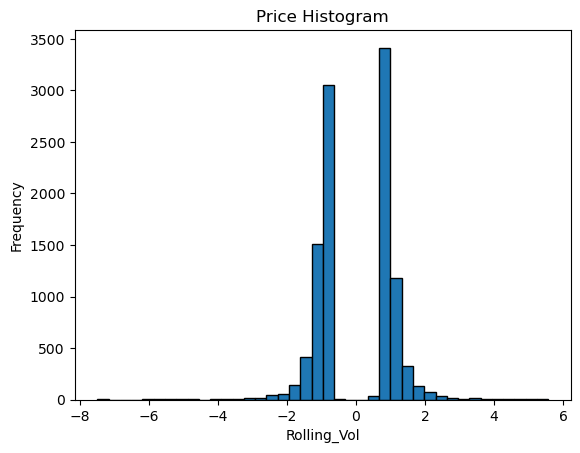

In [592]:
plot_df = test_.filter(
    (pl.col('vwap_diff').abs() >= pl.col('spread'))
)

# Convert the 'price' column to a Pandas Series for plotting
price_data = plot_df['vwap_diff'].to_pandas()

# Plot histogram
plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
plt.title('Price Histogram')
plt.xlabel('Rolling_Vol')
plt.ylabel('Frequency')
plt.show()

#### Download raw data for specific time period

In [405]:
time = 1742429049008000
btc_trades.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_trades_sample.csv')
btc_ob.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_ob_sample.csv')
btc_bbo.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_bbo_sample.csv')

In [426]:
btc_trades_bn.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{1742429045008000}_btc_trades_sample.csv')